In [1]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

import cv2

# Chuẩn hóa

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Giả sử ảnh có giá trị từ min đến max bất kỳ
def normalize_to_uint8(image):
    normalized = (image - image.min()) * (255.0 / (image.max() - image.min()))  # Chuẩn hóa về [0,255]
    return normalized.astype(np.uint8)  # Chuyển về uint8

# Image Infor

In [2]:
img = cv2.imread('Image/bird1.jpg')

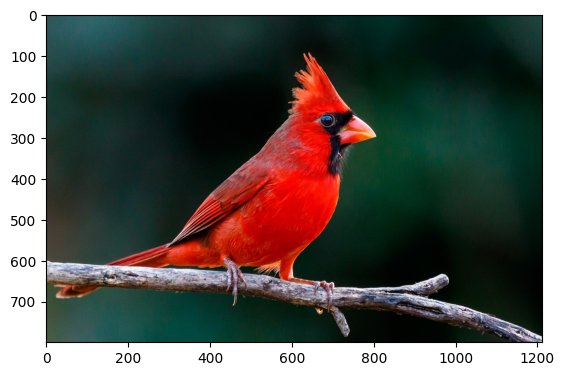

In [3]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

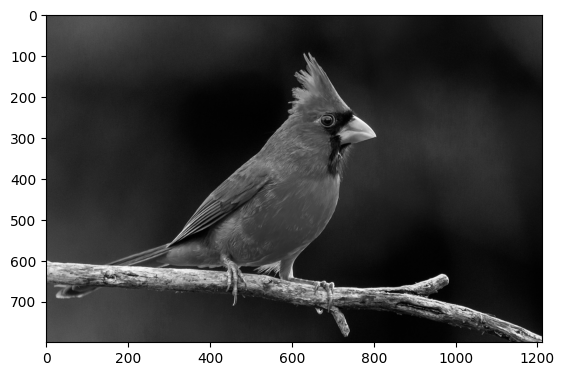

In [4]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray/255, cmap='gray')

In [5]:
img_gray.shape

(800, 1212)

In [6]:
img.shape

(800, 1212, 3)

In [7]:
img_gray.max()

255

# Sobel

### Thuật toán Sobel

Sobel là một thuật toán phát hiện biên trong xử lý ảnh, dựa trên việc tính đạo hàm bậc nhất của cường độ sáng trong ảnh. Nó phát hiện các biên bằng cách tìm những thay đổi nhanh chóng về cường độ sáng, thường xảy ra tại các đường biên của đối tượng trong ảnh.

---

### **Nguyên lý hoạt động**

Sobel sử dụng **toán tử tích chập (convolution operator)** với hai ma trận nhân (kernel) để tính gần đúng đạo hàm bậc nhất theo hai hướng: **hướng ngang (x)** và **hướng dọc (y)**.

1. **Kernel Sobel:**
   - Hướng ngang ($G_x$):
     $$
     K_x = 
     \begin{bmatrix}
     -1 & 0 & 1 \\
     -2 & 0 & 2 \\
     -1 & 0 & 1
     \end{bmatrix}
     $$

   - Hướng dọc ($G_y$):
     $$
     K_y = 
     \begin{bmatrix}
     -1 & -2 & -1 \\
      0 &  0 &  0 \\
      1 &  2 &  1
     \end{bmatrix}
     $$

2. **Tính toán đạo hàm x và y:**
   - Đạo hàm theo hướng ngang ($G_x$): Tích chập ảnh đầu vào với $K_x$.
   - Đạo hàm theo hướng dọc ($G_y$): Tích chập ảnh đầu vào với $K_y$.

3. **Độ lớn biên ($G$):**
   Sau khi tính $G_x$ và $G_y$, độ lớn của biên được tính bằng:
   $$
   G = \sqrt{G_x^2 + G_y^2}
   $$
   (hoặc lấy gần đúng $G = |G_x| + |G_y|$ để giảm chi phí tính toán).

4. **Hướng của biên ($\theta$):**
   Hướng của biên được xác định bằng:
   $$
   \theta = \arctan\left(\frac{G_y}{G_x}\right)
   $$

---

### **Các bước thực hiện thuật toán Sobel**

1. **Tiền xử lý:**
   - Chuyển ảnh sang ảnh grayscale (nếu ảnh đầu vào là RGB).
   - Áp dụng bộ lọc Gaussian để giảm nhiễu (không bắt buộc nhưng khuyến khích).

2. **Tích chập với kernel Sobel:**
   - Áp dụng $K_x$ và $K_y$ lên ảnh bằng tích chập để tính $G_x$ và $G_y$.

3. **Tính độ lớn biên:**
   - Kết hợp $G_x$ và $G_y$ để xác định biên.

4. **Ngưỡng hóa (Thresholding):**
   - Loại bỏ các giá trị nhỏ (không phải biên) bằng cách áp dụng ngưỡng.

---

### **Ưu điểm**
- Đơn giản, dễ thực hiện và hiệu quả.
- Có khả năng làm mịn ảnh (nhờ các trọng số trong kernel).
- Phát hiện biên ở cả hai hướng ngang và dọc.

### **Nhược điểm**
- Không phát hiện tốt biên trong ảnh nhiễu (cần kết hợp với lọc trước).
- Khả năng phân biệt biên mờ hoặc biên mạnh có thể hạn chế.
- Không phát hiện tốt các biên cong phức tạp.

---

### **Ứng dụng**
- Phát hiện biên (Edge detection).
- Tiền xử lý trong các bài toán nhận diện đối tượng, phát hiện vật thể.
- Tăng cường chi tiết trong ảnh.


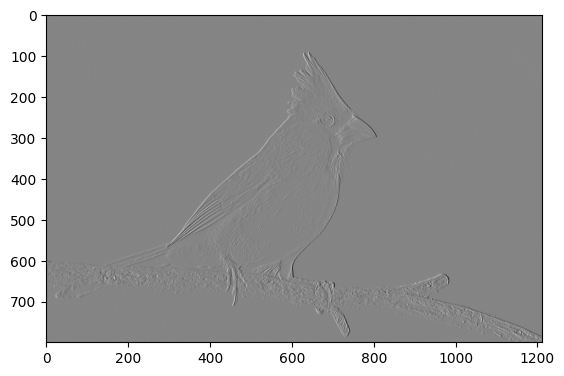

In [8]:
x_sobel = cv2.Sobel(img_gray,cv2.CV_64F,1,0)
plt.imshow(x_sobel, cmap='gray')

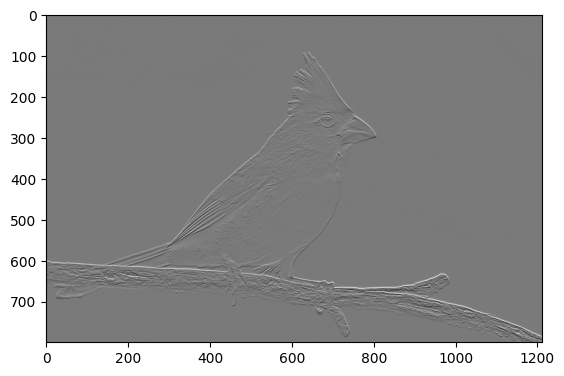

In [9]:
y_sobel = cv2.Sobel(img_gray, cv2.CV_64F, 0,1)
plt.imshow(y_sobel, cmap='gray')

In [10]:
gradient_magnitude_sobel = np.sqrt(x_sobel**2 + y_sobel**2)

In [11]:
gradient_magnitude_sobel

array([[  0.        ,   6.        ,   0.        , ...,  12.        ,
          2.        ,   0.        ],
       [ 12.        ,  16.1245155 ,  14.76482306, ...,  14.14213562,
          7.61577311,   6.        ],
       [  4.        ,  10.        ,  18.60107524, ...,  14.14213562,
          2.82842712,   4.        ],
       ...,
       [ 10.        ,   9.89949494,   2.82842712, ..., 365.01232856,
        440.98526052, 424.        ],
       [  8.        ,   5.83095189,   7.07106781, ...,  56.72741841,
        142.50614022,   4.        ],
       [  0.        ,   0.        ,   6.        , ...,  34.        ,
        158.        ,   0.        ]])

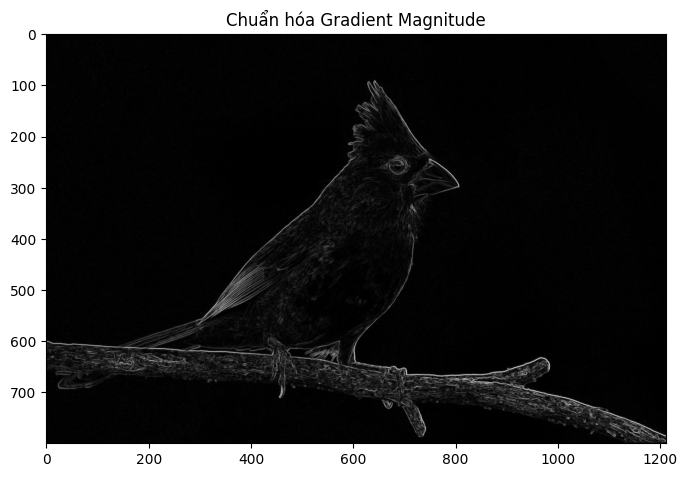

In [12]:
# Chuẩn hóa
min_val = np.min(gradient_magnitude_sobel)
max_val = np.max(gradient_magnitude_sobel)
# Chuẩn hóa về phạm vi [0, 255]
normalized_image = ((gradient_magnitude_sobel - min_val) / (max_val - min_val)) * 255

# Chuyển đổi về kiểu uint8
normalized_image = np.uint8(normalized_image)

# Hiển thị kết quả
plt.figure(figsize=(8, 8))
plt.imshow(normalized_image, cmap='gray')
plt.title('Chuẩn hóa Gradient Magnitude')
plt.show()

# Robert

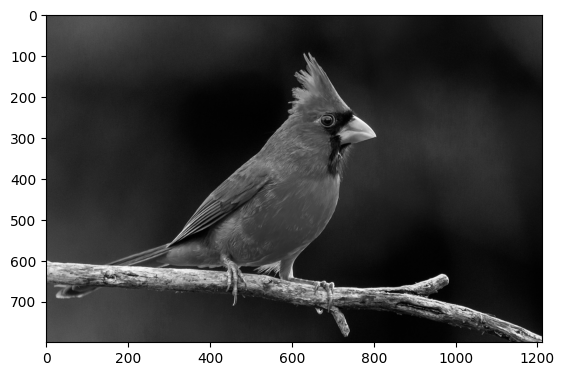

In [13]:
plt.imshow(img_gray, cmap='gray')

In [16]:
img2 = img_gray

In [17]:
robert_x = np.array([[1, 0], [0, -1]])
robert_y = np.array([[0, 1], [-1, 0]])

In [18]:
gradient_x = cv2.filter2D(img2.astype(np.float32), -1, robert_x)
gradient_y = cv2.filter2D(img2.astype(np.float32), -1, robert_y)

| Toán tử   | Kernel                | Phát hiện cạnh theo hướng nào?         |
|-----------|-----------------------|----------------------------------------|
| **Roberts X** | \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}  | Cạnh chéo (45° từ trái sang phải)  |
| **Roberts Y** | \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix}  | Cạnh chéo (135° từ phải sang trái) |


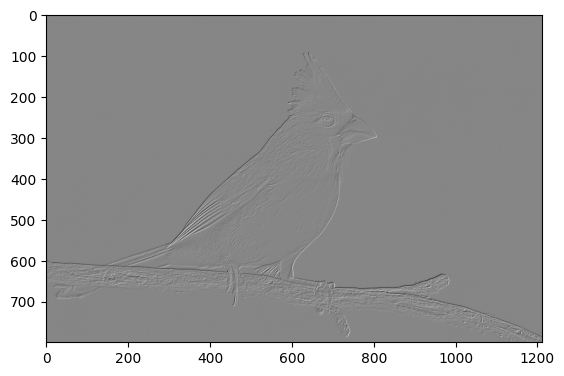

In [19]:
plt.imshow(gradient_x,cmap='gray')

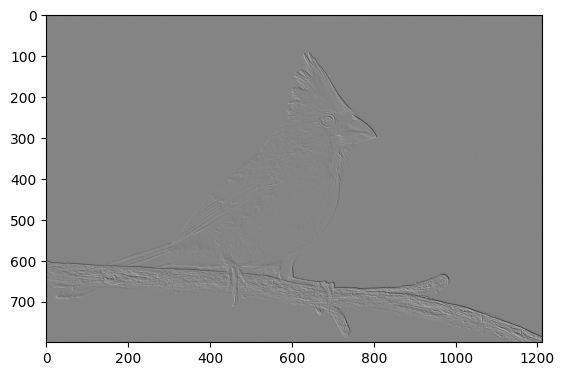

In [20]:
plt.imshow(gradient_y,cmap='gray')

In [21]:
# Tính tổng độ thay đổi
gradient_magnitude_robert = np.sqrt(np.square(gradient_x) + np.square(gradient_y))

In [22]:
gradient_magnitude_robert.max()


256.33768

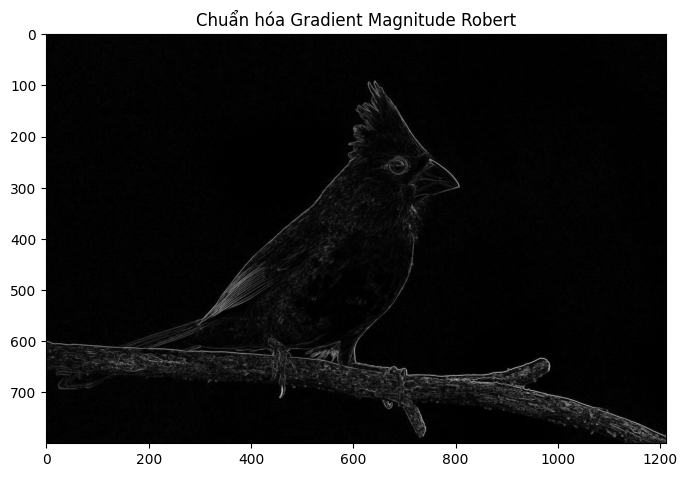

In [23]:
# Chuẩn hóa
min_val = np.min(gradient_magnitude_robert)
max_val = np.max(gradient_magnitude_robert)
# Chuẩn hóa về phạm vi [0, 255]
normalized_image_robert = ((gradient_magnitude_robert - min_val) / (max_val - min_val)) * 255

# Chuyển đổi về kiểu uint8
normalized_image_robert = np.uint8(normalized_image_robert)

# Hiển thị kết quả
plt.figure(figsize=(8, 8))
plt.imshow(normalized_image_robert, cmap='gray')
plt.title('Chuẩn hóa Gradient Magnitude Robert')
plt.show()

# so sanh voi robert voi sobel



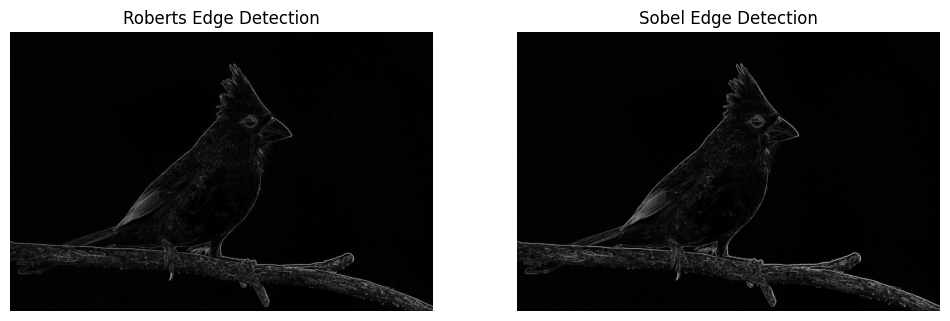

In [24]:
plt.figure(figsize=(12, 12))

# Ảnh Roberts
plt.subplot(1, 2, 1)
plt.imshow(normalized_image_robert, cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')  # Tắt trục tọa độ

# Ảnh Sobel
plt.subplot(1, 2, 2)
plt.imshow(normalized_image, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

# Hiển thị kết quả
plt.show()

- Roberts phát hiện biên nhanh hơn nhưng rất nhạy cảm với nhiễu.

- Sobel làm mượt ảnh trước khi tính toán, giúp giảm nhiễu và phát hiện biên mượt hơn.

- Roberts phù hợp khi cần phát hiện cạnh chi tiết ở mức pixel.

- Sobel thường được dùng trong thực tế vì ổn định hơn và ít nhạy với nhiễu.

# Prewitt

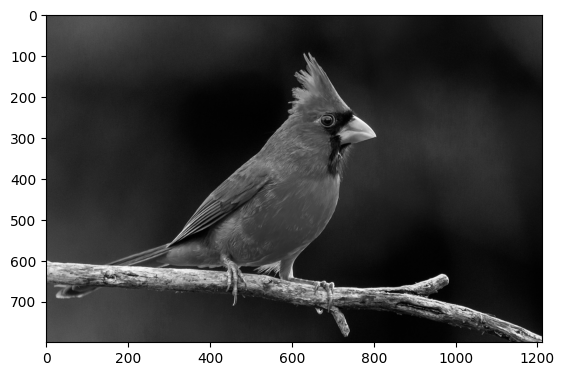

In [25]:
plt.imshow(img_gray, cmap='gray')

In [26]:
img3 = img_gray

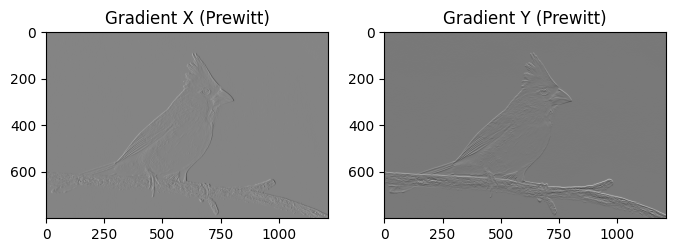

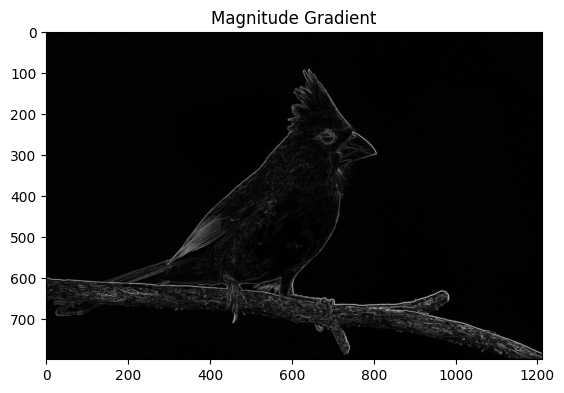

In [27]:
kernel_x_pre = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]])

# Bộ lọc Prewitt theo hướng Y (dọc)
kernel_y_pre = np.array([[-1, -1, -1],
                     [0,  0,  0],
                     [1,  1,  1]])

# Áp dụng bộ lọc Prewitt với filter2D
gradient_x_pre = cv2.filter2D(img3.astype(np.float32), -1, kernel_x_pre)
gradient_y_pre = cv2.filter2D(img3.astype(np.float32), -1, kernel_y_pre)

# # Tính magnitude của gradient
gradient_magnitude_pre = np.sqrt(gradient_x_pre**2 + gradient_y_pre**2)
gradient_magnitude_pre = np.array(gradient_magnitude_pre, dtype=np.float32)

# # Chuẩn hóa về phạm vi [0, 255]
gradient_magnitude_pre_normal = cv2.convertScaleAbs(gradient_magnitude_pre)

# # Hiển thị kết quả
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1), plt.imshow(gradient_x_pre, cmap='gray'), plt.title('Gradient X (Prewitt)')
plt.subplot(1, 2, 2), plt.imshow(gradient_y_pre, cmap='gray'), plt.title('Gradient Y (Prewitt)')

plt.show()
plt.imshow(gradient_magnitude_pre, cmap='gray'), plt.title('Magnitude Gradient')
plt.show()

- Prewitt X: Nhấn mạnh biên theo chiều ngang (phát hiện cạnh dọc).
- Prewitt Y: Nhấn mạnh biên theo chiều dọc (phát hiện cạnh ngang).
- Prewitt đơn giản hơn Sobel vì không có trọng số khác nhau ở trung tâm, nhưng cũng kém chính xác hơn.
- Ứng dụng: Dùng trong phát hiện cạnh đơn giản, nhanh hơn Sobel nhưng dễ bị nhiễu hơn.

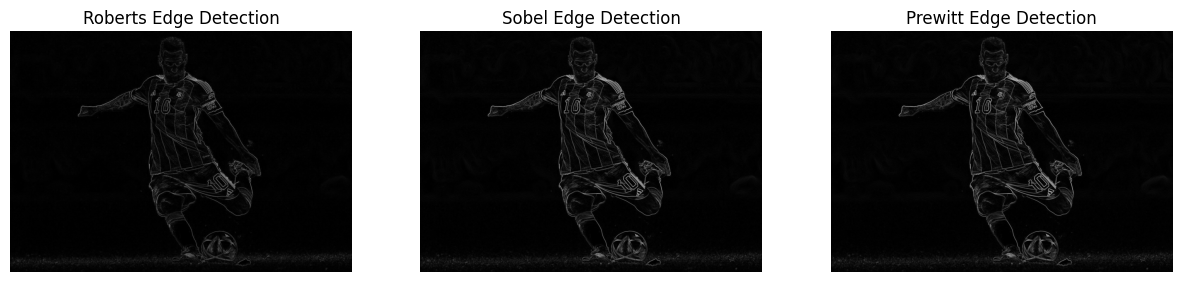

In [26]:
# Tạo figure để hiển thị ảnh
plt.figure(figsize=(15, 5))

# Ảnh Roberts
plt.subplot(1, 3, 1)
plt.imshow(normalized_image_robert, cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')  # Tắt trục tọa độ

# Ảnh Sobel
plt.subplot(1, 3, 2)
plt.imshow(normalized_image, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

# Ảnh Prewitt
plt.subplot(1, 3, 3)
plt.imshow(gradient_magnitude_pre, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')

# Hiển thị kết quả
plt.show()

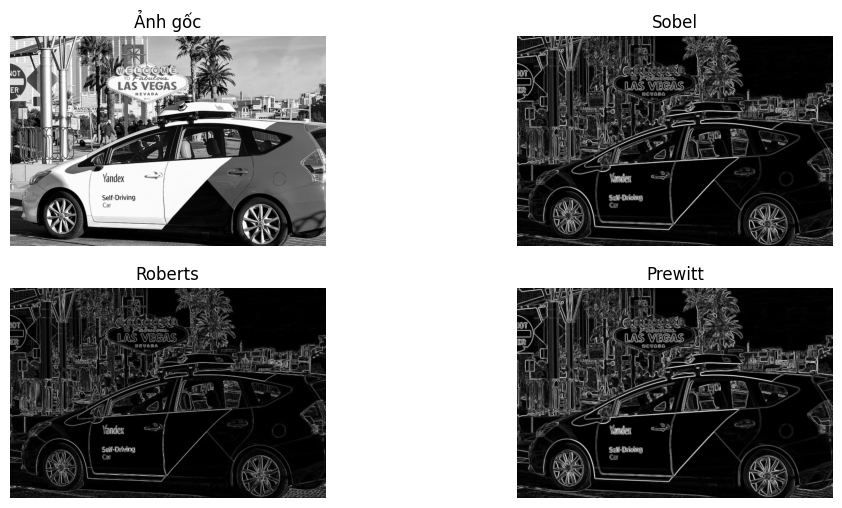

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Đọc ảnh xám
image = cv2.imread("Image/Self_Driving_Car.jpg", cv2.IMREAD_GRAYSCALE)

# Bộ lọc Sobel (3x3)
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)

# Bộ lọc Roberts (2x2)
roberts_x = np.array([[1, 0], [0, -1]])
roberts_y = np.array([[0, 1], [-1, 0]])
roberts_x_res = convolve(image.astype(np.float64), roberts_x)
roberts_y_res = convolve(image.astype(np.float64), roberts_y)
roberts = np.sqrt(roberts_x_res**2 + roberts_y_res**2)

# Bộ lọc Prewitt (3x3)
prewitt_x = cv2.filter2D(image, cv2.CV_64F, np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]]))
prewitt_y = cv2.filter2D(image, cv2.CV_64F, np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]]))
prewitt = np.sqrt(prewitt_x**2 + prewitt_y**2)

# Hiển thị kết quả
plt.figure(figsize=(12,6))
plt.subplot(2,2,1), plt.imshow(image, cmap="gray"), plt.title("Ảnh gốc"), plt.axis("off")
plt.subplot(2,2,2), plt.imshow(normalize_to_uint8(sobel), cmap="gray"), plt.title("Sobel"), plt.axis("off")
plt.subplot(2,2,3), plt.imshow(normalize_to_uint8(roberts), cmap="gray"), plt.title("Roberts"), plt.axis("off")
plt.subplot(2,2,4), plt.imshow(normalize_to_uint8(prewitt), cmap="gray"), plt.title("Prewitt"), plt.axis("off")
plt.show()


# Laplacian

# Thuật toán Laplacian trong Xử lý ảnh

## 1. Khái niệm Laplacian:
Laplacian trong toán học là phép toán vi phân bậc 2, được sử dụng để xác định các điểm cực trị (đỉnh, đáy) của hàm số. Trong xử lý ảnh, Laplacian được áp dụng để đo độ thay đổi cường độ sáng của các pixel, đặc biệt là khi có sự thay đổi mạnh mẽ về độ sáng (ví dụ như các biên).

## 2. Định nghĩa Laplacian trong xử lý ảnh:
Trong ngữ cảnh xử lý ảnh, Laplacian là một phép toán áp dụng lên một ảnh, giúp tính toán sự thay đổi về độ sáng của các pixel xung quanh mỗi pixel trong ảnh. Đơn giản hơn, Laplacian giúp phát hiện các vùng mà tại đó có sự thay đổi đột ngột về độ sáng, ví dụ như các cạnh hoặc biên giữa các đối tượng.

### Công thức toán học:
Laplacian của một hàm ảnh \( I(x, y) \) (với \( x, y \) là chỉ số pixel trong ảnh) trong không gian 2D có thể được mô tả bằng công thức:

$$
\nabla^2 I(x, y) = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
$$

- $$\frac{\partial^2 I}{\partial x^2}$$: Đạo hàm bậc 2 của ảnh theo hướng x (hướng ngang).
- $$\frac{\partial^2 I}{\partial y^2}$$: Đạo hàm bậc 2 của ảnh theo hướng y (hướng dọc).

Kết quả của phép toán Laplacian là một giá trị biểu thị sự thay đổi độ sáng của pixel tại vị trí \( (x, y) \).

## 3. Cách Laplacian phát hiện biên:
- **Cạnh sáng-tối**: Các biên trong ảnh thường là các vùng có sự thay đổi mạnh mẽ giữa sáng và tối. Laplacian có thể phát hiện các biên này, vì sự thay đổi lớn về cường độ sáng sẽ dẫn đến một giá trị lớn trong ảnh Laplacian.
- **Phát hiện điểm cực trị**: Laplacian giúp phát hiện các điểm cực trị, tức là những điểm có sự thay đổi mạnh về độ sáng (chẳng hạn như các đỉnh sáng hoặc đáy tối).

## 4. Bộ lọc Laplacian (Kernel Laplacian):
Laplacian có thể được tính toán thông qua một bộ lọc (kernel). Một trong những bộ lọc phổ biến nhất để tính toán Laplacian là bộ lọc 3x3. Bộ lọc Laplacian chuẩn có dạng như sau:

$$
\begin{bmatrix}
0 &  1 &  0 \\
1 & -4 &  1 \\
0 &  1 &  0
\end{bmatrix}
$$

Hoặc một biến thể khác là:

$$
\begin{bmatrix}
1 &  1 &  1 \\
1 & -8 &  1 \\
1 &  1 &  1
\end{bmatrix}
$$

Các giá trị trong kernel này đại diện cho cách tính toán sự thay đổi độ sáng tại mỗi pixel dựa trên các pixel xung quanh nó. Bộ lọc này áp dụng phép cộng trọng số lên các pixel lân cận để tính toán sự thay đổi độ sáng, và giá trị tại mỗi pixel trong ảnh Laplacian là sự cộng dồn của các giá trị này.

## 5. Các bước trong thuật toán Laplacian:
1. **Chuyển ảnh về ảnh xám (nếu là ảnh màu)**: Laplacian thường được áp dụng trên ảnh xám, vì ảnh xám chỉ có một kênh cường độ sáng duy nhất.
2. **Làm mờ ảnh**: Để giảm nhiễu, ảnh thường được làm mờ trước khi áp dụng phép toán Laplacian (ví dụ: dùng Gaussian Blur).
3. **Áp dụng bộ lọc Laplacian**: Sử dụng một bộ lọc Laplacian (kernel) để tính toán sự thay đổi độ sáng tại mỗi pixel.
4. **Chuyển đổi về giá trị tuyệt đối**: Vì Laplacian có thể trả về các giá trị âm, ta thường lấy giá trị tuyệt đối để chỉ quan tâm đến sự thay đổi, không quan tâm đến chiều (tăng hoặc giảm) của sự thay đổi.
5. **Hiển thị hoặc xử lý thêm**: Ảnh Laplacian sau khi tính toán có thể được sử dụng để phát hiện cạnh hoặc tăng cường các chi tiết trong ảnh.

## 6. Ứng dụng Laplacian trong xử lý ảnh:
- **Phát hiện cạnh**: Laplacian rất hiệu quả trong việc phát hiện các biên cạnh, vì nó nhấn mạnh sự thay đổi mạnh mẽ về cường độ sáng giữa các vùng.
- **Tăng cường chi tiết ảnh**: Trong các ứng dụng như phân tích ảnh y tế hoặc kiểm tra chất lượng, Laplacian có thể giúp làm nổi bật các chi tiết quan trọng trong ảnh.
- **Giảm nhiễu**: Laplacian có thể giúp giảm nhiễu trong ảnh bằng cách làm nổi bật các chi tiết quan trọng và loại bỏ các vùng có sự thay đổi nhẹ về độ sáng.

## 7. Ưu điểm và nhược điểm của Laplacian:
- **Ưu điểm**:
  - Dễ dàng phát hiện biên và các điểm cực trị trong ảnh.
  - Có thể giúp tăng cường các chi tiết ảnh quan trọng.
- **Nhược điểm**:
  - Nhạy cảm với nhiễu, vì các vùng nhiễu có thể tạo ra những thay đổi đột ngột trong độ sáng.
  - Cần phải làm mờ ảnh trước khi áp dụng Laplacian để giảm ảnh hưởng của nhiễu.
  - Chỉ phát hiện sự thay đổi về cường độ ánh sáng mà không quan tâm đến màu sắc trong ảnh.

## 8. Kết luận:
Laplacian là một công cụ mạnh mẽ trong xử lý ảnh, giúp phát hiện biên, tăng cường chi tiết và phát hiện các điểm cực trị. Tuy nhiên, vì sự nhạy cảm với nhiễu, việc làm mờ ảnh trước khi áp dụng Laplacian là rất quan trọng.


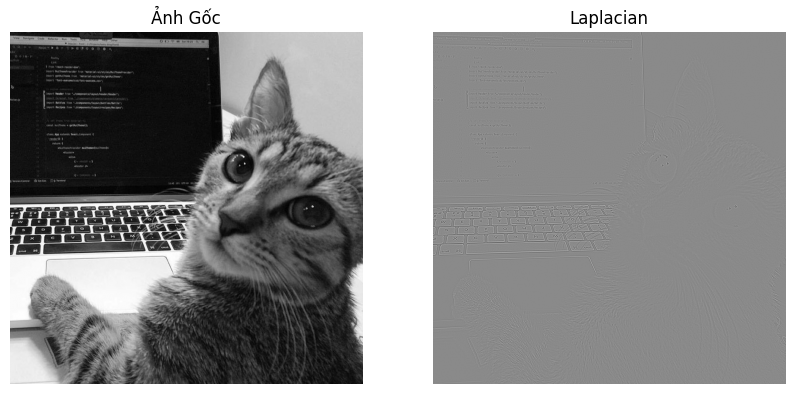

In [28]:

image = cv2.imread('Image/d7b2e52d246dffe794a6a1c750a05593.jpg', cv2.IMREAD_GRAYSCALE)

# Áp dụng toán tử Laplacian
laplacian = cv2.Laplacian(image, cv2.CV_64F)  # Kết quả có thể chứa giá trị âm



# Áp dụng chuẩn hóa
# laplacian_normalized = normalize_to_uint8(laplacian)

# Hiển thị ảnh gốc và ảnh Laplacian
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Ảnh Gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian")
plt.axis("off")

plt.show()


# Tăng cường ảnh

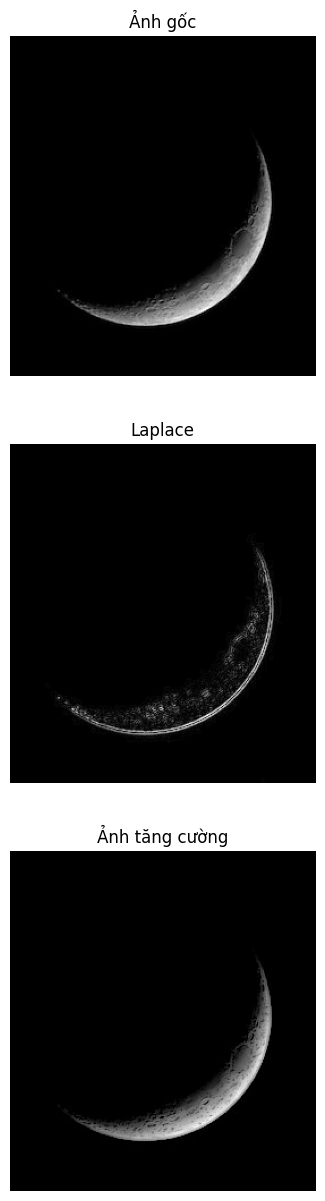

In [30]:

image = cv2.imread('Image/moon.jpg', cv2.IMREAD_GRAYSCALE)  # Đọc ảnh xám

# Làm mờ ảnh để giảm nhiễu
blurred = cv2.GaussianBlur(image, (3, 3), 0)

# Áp dụng toán tử Laplacian
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)

# Chuyển về dạng tuyệt đối và sử dụng convertScaleAbs
laplacian = cv2.convertScaleAbs(laplacian)

# Hiển thị kết quả
alpha = 1.0  # Hệ số điều chỉnh
enhanced = cv2.subtract(image, np.uint8(alpha * laplacian))

# Hiển thị kết quả
plt.figure(figsize=(16, 15))  # Điều chỉnh kích thước ảnh lớn hơn

# Ảnh gốc
plt.subplot(3, 1, 1)
plt.imshow(image, cmap='gray')
plt.title("Ảnh gốc")
plt.axis("off")

# Ảnh Laplacian
plt.subplot(3, 1, 2)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplace")
plt.axis("off")

# Ảnh tăng cường
plt.subplot(3, 1, 3)
plt.imshow(enhanced, cmap='gray')
plt.title("Ảnh tăng cường")
plt.axis("off")

plt.show()


In [ ]:
import cv2
import numpy as np

# Đọc ảnh gốc
img = cv2.imread('Image/moon.jpg', cv2.IMREAD_GRAYSCALE)

# Áp dụng bộ lọc Laplacian
laplacian = cv2.Laplacian(img, cv2.CV_64F)

# Chuyển ảnh Laplacian về dạng uint8
laplacian_abs = cv2.convertScaleAbs(laplacian)

# Tăng cường ảnh bằng cách trừ ảnh Laplacian khỏi ảnh gốc
enhanced_img = cv2.subtract(img, laplacian_abs)

# Thay đổi kích thước ảnh để hiển thị nhỏ hơn (đặt kích thước cố định)
new_width = 600  # Chiều rộng mới
new_height = int(img.shape[0] * (new_width / img.shape[1]))  # Giữ tỷ lệ chiều cao và chiều rộng

# Resize cả ảnh gốc và ảnh đã tăng cường
img_resized = cv2.resize(img, (new_width, new_height))
enhanced_img_resized = cv2.resize(enhanced_img, (new_width, new_height))

# Hiển thị ảnh gốc và ảnh đã tăng cường
cv2.imshow('Original Image', img_resized)
cv2.imshow('Enhanced Image', enhanced_img_resized)

cv2.waitKey(0)
cv2.destroyAllWindows()


In [62]:
cv2.imshow('Laplacian', laplacian)
cv2.waitKey()
cv2.destroyAllWindows()



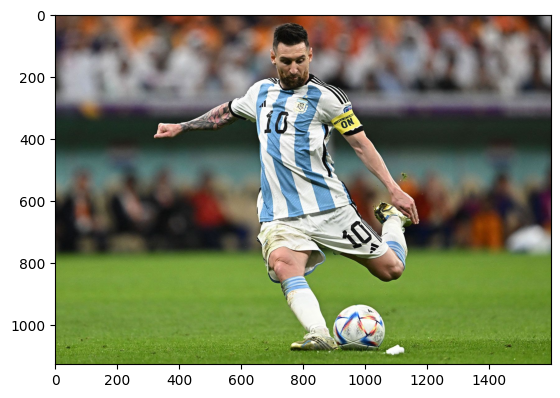

In [59]:
plt.imshow(img_rgb)